# Lab Day 1 — Xây dựng mạng nơ-ron và thí nghiệm huấn luyện
**Đặng Hữu Tâm — 2A202602940** · Forest CoverType · chủ đề thí nghiệm: **hyper-parameter** (theo yêu cầu giảng viên, chỉ một chủ đề)

> **Quy trình chạy lại**
> 1. Mở `submission_2A202602940/code/lab.ipynb` và làm việc **tại đó** (`REPO_ROOT = "../.."`, ảnh/kết quả ghi vào `submission_2A202602940/figures`, `results`).
> 2. Ở Colab: ô đầu tiên tự mount Google Drive, clone/pull repo vào Drive rồi chuyển vào thư mục `code/`.
> 3. `Restart & Run All` chạy hết từ đầu (≈ 10 phút trên T4) và tạo lại toàn bộ ảnh, JSON, bảng, dự đoán eval.
> 4. Báo cáo: `../REPORT.md`; bảng: `../experiments.xlsx`; dự đoán nộp: `../predictions_eval.csv` (cấu hình cuối `hp-wide-ep40-s1`).

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch


MSSV     = "2A202602940"
REPO_URL = "https://github.com/tam253211-a11y/K4-Track4-DangHuuTam-2A202602940-Neuralnetwork.git"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Repo nằm trên Google Drive để figures/, results/ không mất khi Colab ngắt kết nối.
    from google.colab import drive
    drive.mount("/content/drive")
    COLAB_REPO = "/content/drive/MyDrive/K4-Track4-DangHuuTam-2A202602940-Neuralnetwork"
    if not os.path.isdir(COLAB_REPO):
        subprocess.run(["git", "clone", REPO_URL, COLAB_REPO], check=True)
    else:
        subprocess.run(["git", "-C", COLAB_REPO, "pull", "--ff-only"], check=False)
    # Làm việc tại submission_<MSSV>/code/ để REPO_ROOT = "../.." và OUT_DIR = ".." đúng như khi chạy local.
    os.chdir(f"{COLAB_REPO}/submission_{MSSV}/code")

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
assert os.path.isfile(f"{REPO_ROOT}/scripts/split_data.py"), f"REPO_ROOT sai: {os.path.abspath(REPO_ROOT)}"
assert os.path.basename(os.path.abspath(OUT_DIR)) == f"submission_{MSSV}", f"OUT_DIR sai: {os.path.abspath(OUT_DIR)}"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("cwd      :", os.getcwd())
print("REPO_ROOT:", os.path.abspath(REPO_ROOT))
print("OUT_DIR  :", os.path.abspath(OUT_DIR))
print("torch    :", torch.__version__, "| device:", device)
if device.type == "cuda":
    print("GPU      :", torch.cuda.get_device_name(0), "| bf16 supported:", torch.cuda.is_bf16_supported())

os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)

from data import prepare_data, iterate_batches
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd      : /content/drive/MyDrive/K4-Track4-DangHuuTam-2A202602940-Neuralnetwork/submission_2A202602940/code
REPO_ROOT: /content/drive/MyDrive/K4-Track4-DangHuuTam-2A202602940-Neuralnetwork
OUT_DIR  : /content/drive/MyDrive/K4-Track4-DangHuuTam-2A202602940-Neuralnetwork/submission_2A202602940
torch    : 2.11.0+cu130 | device: cuda
GPU      : Tesla T4 | bf16 supported: True


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.

In [2]:
# Chia train/eval theo metadata (script tự kiểm tra số dòng, row_id, số mẫu mỗi tập). Chạy từ gốc repo.
r = subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True, capture_output=True, text=True)
print(r.stdout)

data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=f"{REPO_ROOT}/data/processed")

# --- Kích thước và kiểu
assert len(data["X_tr"]) == 371_847 and len(data["X_val"]) == 92_962 and len(data["X_eval"]) == 116_203
assert all(data[k].dtype == torch.float32 and data[k].shape[1] == 54 for k in ("X_tr", "X_val", "X_eval"))
assert all(data[k].dtype == torch.int64 for k in ("y_tr", "y_val", "y_eval"))

# --- Tỉ lệ lớp ở train / val / eval (phân tầng -> gần như bằng nhau)
print("\nlớp   train(%)   val(%)   eval(%)")
props = {k: torch.bincount(data[k], minlength=7).double() / len(data[k]) * 100 for k in ("y_tr", "y_val", "y_eval")}
for c in range(7):
    print(f"{c:>3d}   {props['y_tr'][c]:7.3f}  {props['y_val'][c]:7.3f}  {props['y_eval'][c]:7.3f}")

# --- Thống kê chuẩn hoá: 10 cột số trên X_tr ~ 0 / 1; 44 cột nhị phân vẫn chỉ có 0/1
num = data["X_tr"][:, :10].double()
print("\nmean 10 cột số trên X_tr:", num.mean(0).cpu().numpy().round(4))
print("std  10 cột số trên X_tr:", num.std(0).cpu().numpy().round(4))
assert num.mean(0).abs().max() < 1e-3 and (num.std(0) - 1).abs().max() < 1e-2
assert torch.isin(data["X_tr"][:, 10:], torch.tensor([0.0, 1.0], device=device)).all()
# val/eval chỉ được BIẾN ĐỔI bằng mean/std của train nên trung bình của chúng không đúng bằng 0 — đó là bình thường
print("mean |cột số| trên X_val:", round(data["X_val"][:, :10].mean(0).abs().max().item(), 4),
      "| trên X_eval:", round(data["X_eval"][:, :10].mean(0).abs().max().item(), 4))

# --- eval_row_id vẫn gắn đúng thứ tự mẫu eval (cùng thứ tự với eval.npz, dùng để ghi predictions_eval.csv)
_ev = np.load(f"{REPO_ROOT}/data/processed/eval.npz")
assert np.array_equal(data["eval_row_id"], _ev["row_id"]) and np.array_equal(data["y_eval"].cpu().numpy(), _ev["y"])
print("eval_row_id:", data["eval_row_id"][:5], "... (", len(data["eval_row_id"]), "dòng, khớp eval.npz )")

# --- Lô cuối: giữ lại (drop_last=False). 371 847 = 726*512 + 135 -> 727 bước/epoch
n_batches = sum(1 for _ in iterate_batches(data["X_tr"], data["y_tr"], 512, shuffle=False))
print(f"\nSố lô/epoch với batch 512: {n_batches} (lô cuối {len(data['X_tr']) % 512} mẫu)")
print(f"Mốc 'đoán đa số' trên val: {data['majority_val_acc']:.4f} (GUIDE: ≈ 0.4876)")

train: X (464809, 54) float32, y (464809,) int64, nhãn 0..6 -> data/processed/train.npz
eval : X (116203, 54) float32, y (116203,) int64, nhãn 0..6 -> data/processed/eval.npz

lớp   train(%)   eval(%)
  0    36.461    36.460
  1    48.760    48.760
  2     6.154     6.154
  3     0.473     0.472
  4     1.634     1.634
  5     2.989     2.989
  6     3.530     3.530

đoán luôn lớp đa số (lớp 1) cho accuracy trên eval = 0.4876

X_tr   (371847, 54) torch.float32 | y_tr   (371847,) torch.int64 | device cuda:0
X_val  (92962, 54) torch.float32 | y_val  (92962,) torch.int64 | device cuda:0
X_eval (116203, 54) torch.float32 | y_eval (116203,) torch.int64 | device cuda:0
Đoán luôn lớp đa số (lớp 1) -> val accuracy = 0.4876

lớp   train(%)   val(%)   eval(%)
  0    36.461   36.460   36.460
  1    48.760   48.760   48.760
  2     6.154    6.154    6.154
  3     0.473    0.472    0.472
  4     1.634    1.634    1.634
  5     2.989    2.989    2.989
  6     3.530    3.530    3.530

mean 10 cột số 

**Nhận xét Part 0:**
- **Kích thước:** train gốc 464 809 → tách 20% val (phân tầng theo nhãn, seed 42) còn **371 847 train / 92 962 val**; eval **116 203** giữ nguyên theo `split_metadata.csv`. Tỉ lệ 7 lớp ở train/val/eval gần như trùng nhau (lớp 1: 48,760% / 48,760% / 48,760%; lớp hiếm nhất là lớp 3: 0,473% / 0,472% / 0,472%), đúng tác dụng của phân tầng.
- **Seed:** seed tách val cố định 42 cho mọi thí nghiệm; khi đo nhiễu chỉ đổi seed huấn luyện, nên mọi thí nghiệm được so trên cùng một tập val.
- **Chuẩn hoá:** chỉ 10 cột số, mean/std tính **trên X_tr**. Sau chuẩn hoá, X_tr có mean = 0 và std = 1 ở cả 10 cột. 44 cột one-hot giữ nguyên 0/1 (đã cùng thang đo).
- **Vì sao val và eval không tham gia tính mean/std:** val dùng để chọn lr, cấu hình và epoch; eval chỉ dùng để chấm điểm cuối. Nếu thống kê của hai tập này được đưa vào bước chuẩn hoá thì mô hình đã gián tiếp "nhìn thấy" dữ liệu dùng để đánh giá nó (rò rỉ dữ liệu), làm số đo trên val/eval lạc quan hơn so với dữ liệu thật sự mới. Val và eval chỉ được **áp dụng** cùng phép biến đổi đã tính từ train: vì vậy mean của chúng gần 0 nhưng không đúng bằng 0 (đo được |mean| lớn nhất 0,0063 trên val và 0,0072 trên eval).
- **`eval_row_id`** giữ đúng thứ tự của `eval.npz` (đã kiểm tra khớp), dùng để ghép dự đoán khi ghi `predictions_eval.csv` ở Part 4.
- **Lô cuối:** giữ lại lô cuối nhỏ hơn: 371 847 = 726 × 512 + **135**, nên mỗi epoch có **727 bước**, mọi mẫu train đều được dùng. Loss lấy trung bình trên lô nên lô nhỏ không làm sai thang đo, chỉ có 1/727 bước có gradient nhiễu hơn.
- **Mốc thấp nhất:** luôn đoán lớp 1 cho val accuracy = **0,4876**; mọi mô hình phải vượt mốc này.


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)
Số tham số: 47,879  (M-base yêu cầu 47,879)
  net.0.weight   (256, 54)    13,824
  net.0.bias     (256,)          256
  net.2.weight   (128, 256)   32,768
  net.2.bias     (128,)          128
  net.4.weight   (7, 128)        896
  net.4.bias     (7,)              7

Đầu vào: (8, 54)
  sau Linear  -> (8, 256)
  sau ReLU    -> (8, 256)
  sau Linear  -> (8, 128)
  sau ReLU    -> (8, 128)
  sau Linear  -> (8, 7)
logits: (8, 7) torch.float32 (logit thô, chưa softmax)

Loss bước 0 trên val = 2.2691   |   ln 7 = 1.9459   |   chênh +0.3232
std của logits ở bước 0 = 0.579
std kích hoạt (sau ReLU1, sau ReLU2, logits) trên 4096 mẫu val: [0.39, 0.366, 0.577]

Chuẩn gradient sau 1 lần backward (lô 512 mẫu train):
  W1 (net.0.weight) ‖g‖ = 5.0705e-01
  b1 (

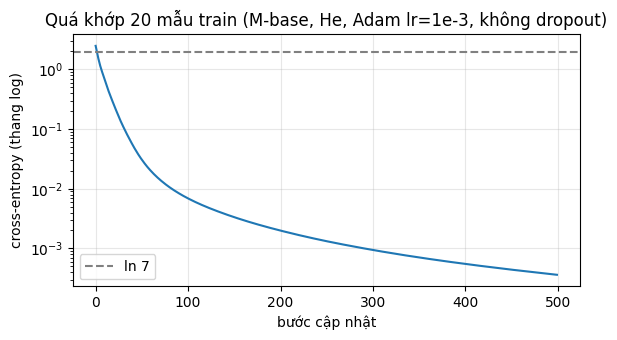

In [3]:
import math
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ---------- 1b. Model, số tham số, shape ----------
set_seed(1)
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
n_params = count_params(model)
assert n_params == EXPECTED_PARAMS[(256, 128)] == 47_879, n_params
print(model)
print(f"Số tham số: {n_params:,}  (M-base yêu cầu 47,879)")
for name, p in model.named_parameters():
    print(f"  {name:<14s} {str(tuple(p.shape)):<12s} {p.numel():>6,}")

xb = torch.randn(8, 54, device=device)
h = xb
print(f"\nĐầu vào: {tuple(h.shape)}")
for layer in model.net:
    h = layer(h)
    print(f"  sau {layer.__class__.__name__:<7s} -> {tuple(h.shape)}")
logits = model(xb)
assert logits.shape == (8, 7) and logits.dtype == torch.float32
assert not any(isinstance(m, nn.Softmax) for m in model.modules()), "không được có softmax trong model"
print("logits:", tuple(logits.shape), logits.dtype, "(logit thô, chưa softmax)")

# ---------- 1c-1. Loss bước 0 trên toàn bộ val (eval mode) ----------
model.eval()
with torch.no_grad():
    val_logits = model(data["X_val"])
    step0_loss = F.cross_entropy(val_logits, data["y_val"]).item()
print(f"\nLoss bước 0 trên val = {step0_loss:.4f}   |   ln 7 = {math.log(7):.4f}   |   chênh {step0_loss - math.log(7):+.4f}")
print(f"std của logits ở bước 0 = {val_logits.std().item():.3f}")
print("std kích hoạt (sau ReLU1, sau ReLU2, logits) trên 4096 mẫu val:",
      [round(s, 3) for s in activation_stats(model, data["X_val"][:4096])])

# ---------- 1d. Gradient chảy tới mọi tham số ----------
model.train()
model.zero_grad(set_to_none=True)
xb, yb = data["X_tr"][:512], data["y_tr"][:512]
F.cross_entropy(model(xb), yb).backward()
print("\nChuẩn gradient sau 1 lần backward (lô 512 mẫu train):")
for (name, p), alias in zip(model.named_parameters(), ["W1", "b1", "W2", "b2", "W3", "b3"]):
    g = p.grad
    assert g is not None, f"{name} không có gradient"
    gn = g.norm().item()
    assert gn > 0, f"{name} có gradient bằng 0"
    print(f"  {alias} ({name:<12s}) ‖g‖ = {gn:.4e}")
print("-> mọi tham số đều có gradient khác None và khác 0")

# ---------- 1c-2. Quá khớp 20 mẫu ----------
set_seed(1)
tiny = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
idx = torch.arange(20, device=device)
x20, y20 = data["X_tr"][idx], data["y_tr"][idx]
print("\n20 mẫu, nhãn:", y20.tolist())
opt = torch.optim.Adam(tiny.parameters(), lr=1e-3)
losses = []
tiny.train()
for step in range(500):
    loss = F.cross_entropy(tiny(x20), y20)
    opt.zero_grad(set_to_none=True)
    loss.backward()
    opt.step()
    losses.append(loss.item())
tiny.eval()
with torch.no_grad():
    acc20 = (tiny(x20).argmax(1) == y20).float().mean().item()
print(f"Loss: bước 0 = {losses[0]:.4f}, bước 100 = {losses[100]:.4f}, bước 499 = {losses[-1]:.2e} | accuracy trên 20 mẫu = {acc20:.0%}")
assert losses[-1] < 0.01 and acc20 == 1.0, "không quá khớp được 20 mẫu -> nhiều khả năng có lỗi code"

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(losses)
ax.axhline(math.log(7), ls="--", c="gray", label="ln 7")
ax.set_xlabel("bước cập nhật"); ax.set_ylabel("cross-entropy (thang log)")
ax.set_title("Quá khớp 20 mẫu train (M-base, He, Adam lr=1e-3, không dropout)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Nhận xét Part 1:**
- **Kiến trúc:** `M-base` = Linear(54→256) → ReLU → Linear(256→128) → ReLU → Linear(128→7), mọi lớp có bias, không softmax, không dropout (q = 0). Tổng **47 879 tham số** (13 824 + 256 + 32 768 + 128 + 896 + 7), khớp quy định; lô (8, 54) đi qua cho logits **(8, 7)**. Khởi tạo He (`kaiming_normal_`, fan_in, ReLU), bias = 0.
- **Loss bước 0 (đo thực, toàn bộ val, chế độ eval):** **2,2691**, so với mốc ln 7 = 1,9459 thì **cao hơn 0,32**.
  - ln 7 là loss khi mọi logit bằng nhau (softmax đều 1/7 cho mỗi lớp). Với He init, lớp cuối cũng có trọng số ngẫu nhiên nên logits đã lệch nhau ngay từ đầu (**std logits = 0,579**): mỗi mẫu bị dự đoán "hơi tự tin" vào một lớp ngẫu nhiên, đúng thì loss giảm ít, sai thì loss tăng nhiều hơn, nên trung bình cao hơn ln 7.
  - Mức lệch 0,32 là nhỏ: không phải triệu chứng "loss bước 0 cao hơn ln 7 nhiều" (điểm số lớp cuối quá lớn / thiếu chuẩn hoá) trong bảng chẩn đoán. Đầu vào đã chuẩn hoá ở Part 0, std kích hoạt sau ReLU1 / ReLU2 ổn định (0,39 / 0,37), không bùng nổ hay tắt dần. Nếu muốn loss bước 0 sát ln 7 hơn có thể thu nhỏ trọng số lớp cuối; mình giữ nguyên để baseline đúng "He" như quy định.
- **Gradient:** sau một lần `backward()` trên lô 512 mẫu, cả 6 tham số W1, b1, W2, b2, W3, b3 đều có gradient khác None và khác 0 (‖g‖ từ 0,34 đến 2,02): gradient chảy tới mọi lớp, không có tham số "chết" hay bị bỏ khỏi đồ thị tính toán.
- **Quá khớp 20 mẫu** (tắt dropout, Adam lr = 1e-3, 500 bước): loss **2,4803 → 0,0069 (bước 100) → 3,62e-4 (bước 499)**, accuracy **100%** trên chính 20 mẫu. Model và vòng cập nhật (nhãn int64 0..6, logit thô vào cross-entropy, `zero_grad`, đủ tham số trong optimizer) phối hợp đúng. Đây chỉ là bằng chứng mô hình *khớp được* một lô nhỏ, **chưa** nói gì về khả năng tổng quát hoá.
- **Kết luận:** pipeline dữ liệu và model đã qua các phép thử rẻ nhất trước khi chạy dài. Nếu baseline sau này không học, lỗi nhiều khả năng nằm ở vòng huấn luyện / lr chứ không phải ở dữ liệu hay kiến trúc.


## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

[base-lr0.003] sgd_momentum lr=0.003 batch=512 loss=ce init=he dropout=0.0 clip=None fp32 seed=1 | 47,879 tham số | step0 val_loss=2.2691
  ep  1 | train 0.6493 | val 0.6521 acc 0.7299 F1 0.4072 | gn 0.427 (max 2.90) | 1.6s *
  ep  2 | train 0.6018 | val 0.6055 acc 0.7451 F1 0.4877 | gn 0.393 (max 0.69) | 1.2s *
  ep  3 | train 0.5763 | val 0.5803 acc 0.7555 F1 0.5083 | gn 0.422 (max 0.86) | 1.2s *
  ep  4 | train 0.5572 | val 0.5611 acc 0.7634 F1 0.5370 | gn 0.449 (max 1.42) | 1.2s *
  ep  5 | train 0.5409 | val 0.5451 acc 0.7699 F1 0.5591 | gn 0.475 (max 0.98) | 1.2s *
  ep  6 | train 0.5298 | val 0.5344 acc 0.7741 F1 0.5747 | gn 0.510 (max 1.24) | 1.3s *
  ep  7 | train 0.5144 | val 0.5183 acc 0.7812 F1 0.5927 | gn 0.538 (max 1.05) | 1.4s *
  ep  8 | train 0.5031 | val 0.5072 acc 0.7875 F1 0.6090 | gn 0.566 (max 1.38) | 1.3s *
  ep  9 | train 0.4926 | val 0.4970 acc 0.7911 F1 0.6024 | gn 0.599 (max 1.23) | 1.4s *
  ep 10 | train 0.4823 | val 0.4866 acc 0.7958 F1 0.6237 | gn 0.616 (m

,exp_id,lr,best_epoch,best_val_loss,val_acc,val_macro_f1,final_train_loss,final_val_loss,time_per_epoch_s,diverged
0,base-lr0.003,0.003,20,0.4198,0.8250,0.6647,0.4136,0.4198,1.3226,False
1,base-lr0.01,0.010,20,0.3110,0.8747,0.7613,0.2994,0.3110,1.3433,False
2,base-lr0.03,0.030,20,0.2660,0.8921,0.8170,0.2473,0.2660,1.2868,False
3,base-lr0.1,0.100,18,0.2379,0.9054,0.8390,0.2218,0.2426,1.2877,False
4,base-lr0.3,0.300,19,0.2318,0.9090,0.8573,0.2057,0.2339,1.2872,False



=> lr chọn cho baseline: 0.3


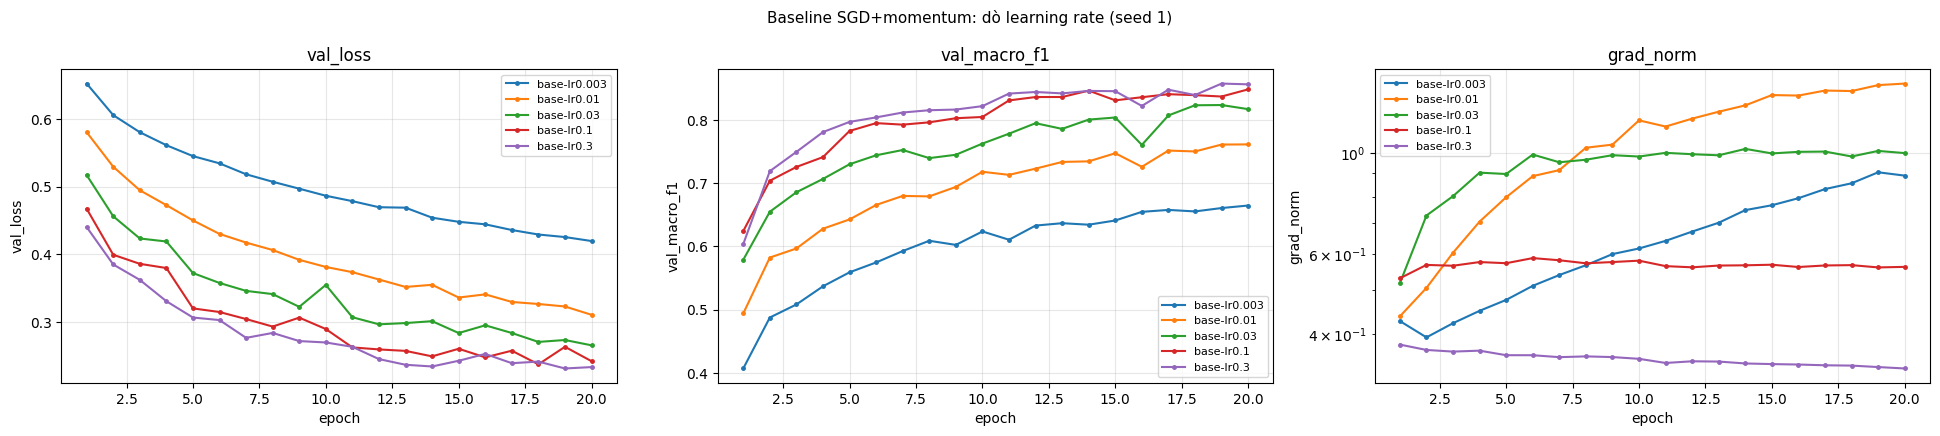

In [3]:
# ===== 2a. Chọn lr cho baseline bằng VAL (SGD + momentum 0.9, mọi thứ khác giữ baseline, seed 1) =====
import pandas as pd
from IPython.display import Image, display
from train import run_and_log

LR_GRID = [0.003, 0.01, 0.03, 0.1, 0.3]      # quanh gợi ý 0.01–0.1 của GUIDE, thêm 2 đầu mút để thấy "quá nhỏ"/"quá lớn"
lr_runs = []
for lr in LR_GRID:
    cfg_lr = {**DEFAULT_CFG, "lr": lr, "seed": 1, "exp_id": f"base-lr{lr:g}", "group": "baseline-lr",
              "description": f"Baseline M-base, dò lr = {lr:g} (chọn lr bằng val)"}
    lr_runs.append(run_and_log(cfg_lr, data, OUT_DIR))

lr_table = pd.DataFrame([{"exp_id": r["cfg"]["exp_id"], "lr": r["cfg"]["lr"], **{k: r["summary"][k] for k in
           ("best_epoch", "best_val_loss", "val_acc", "val_macro_f1", "final_train_loss", "final_val_loss",
            "time_per_epoch_s", "diverged")}} for r in lr_runs])
display(lr_table.round(4))

# Chọn lr: val macro-F1 cao nhất (chỉ số chính), CHỈ dựa trên val
ok = lr_table[~lr_table["diverged"]]
BEST_LR = float(ok.loc[ok["val_macro_f1"].idxmax(), "lr"])
print(f"\n=> lr chọn cho baseline: {BEST_LR:g}")
cfg = {**DEFAULT_CFG, "lr": BEST_LR}

plot_compare(lr_runs, ["val_loss", "val_macro_f1", "grad_norm"], f"{OUT_DIR}/figures/compare_baseline-lr.png",
             title="Baseline SGD+momentum: dò learning rate (seed 1)", show=True)


[base-s1] sgd_momentum lr=0.3 batch=512 loss=ce init=he dropout=0.0 clip=None fp32 seed=1 | 47,879 tham số | step0 val_loss=2.2691
  ep  1 | train 0.4350 | val 0.4404 acc 0.8127 F1 0.6037 | gn 0.379 (max 2.84) | 1.4s *
  ep  2 | train 0.3784 | val 0.3852 acc 0.8383 F1 0.7190 | gn 0.369 (max 0.64) | 1.2s *
  ep  3 | train 0.3538 | val 0.3625 acc 0.8464 F1 0.7494 | gn 0.365 (max 0.67) | 1.3s *
  ep  4 | train 0.3180 | val 0.3310 acc 0.8650 F1 0.7807 | gn 0.367 (max 0.71) | 1.3s *
  ep  5 | train 0.2932 | val 0.3070 acc 0.8748 F1 0.7968 | gn 0.359 (max 0.56) | 1.2s *
  ep  6 | train 0.2929 | val 0.3032 acc 0.8760 F1 0.8039 | gn 0.359 (max 0.72) | 1.2s *
  ep  7 | train 0.2650 | val 0.2770 acc 0.8860 F1 0.8116 | gn 0.355 (max 0.64) | 1.2s *
  ep  8 | train 0.2693 | val 0.2842 acc 0.8847 F1 0.8152 | gn 0.357 (max 0.59) | 1.2s
  ep  9 | train 0.2544 | val 0.2722 acc 0.8899 F1 0.8163 | gn 0.355 (max 0.55) | 1.3s *
  ep 10 | train 0.2528 | val 0.2702 acc 0.8899 F1 0.8217 | gn 0.352 (max 0.63) 

,exp_id,seed,step0_loss,best_epoch,best_val_loss,val_acc,val_macro_f1,final_train_loss,final_val_loss,time_per_epoch_s,peak_mem_MB
0,base-s1,1,2.2691,19,0.2318,0.9090,0.8573,0.2057,0.2339,1.2854,199.1074
1,base-s2,2,1.9782,16,0.2145,0.9144,0.8618,0.1964,0.2251,1.2864,199.1074
2,base-s3,3,1.9005,18,0.2208,0.9121,0.8630,0.2087,0.2337,1.2835,199.1074


,val_acc,val_macro_f1,best_val_loss
mean,0.9118,0.8607,0.2224
std,0.0027,0.0030,0.0088


val macro-F1 baseline = 0.8607 ± 0.0030  ->  ngưỡng nhiễu 2σ = 0.0060
val acc baseline      = 0.9118 ± 0.0027  (mốc đoán đa số 0.4876)
base-s1 lặp lại base-lr0.3: chênh val_macro_f1 = 0.00e+00


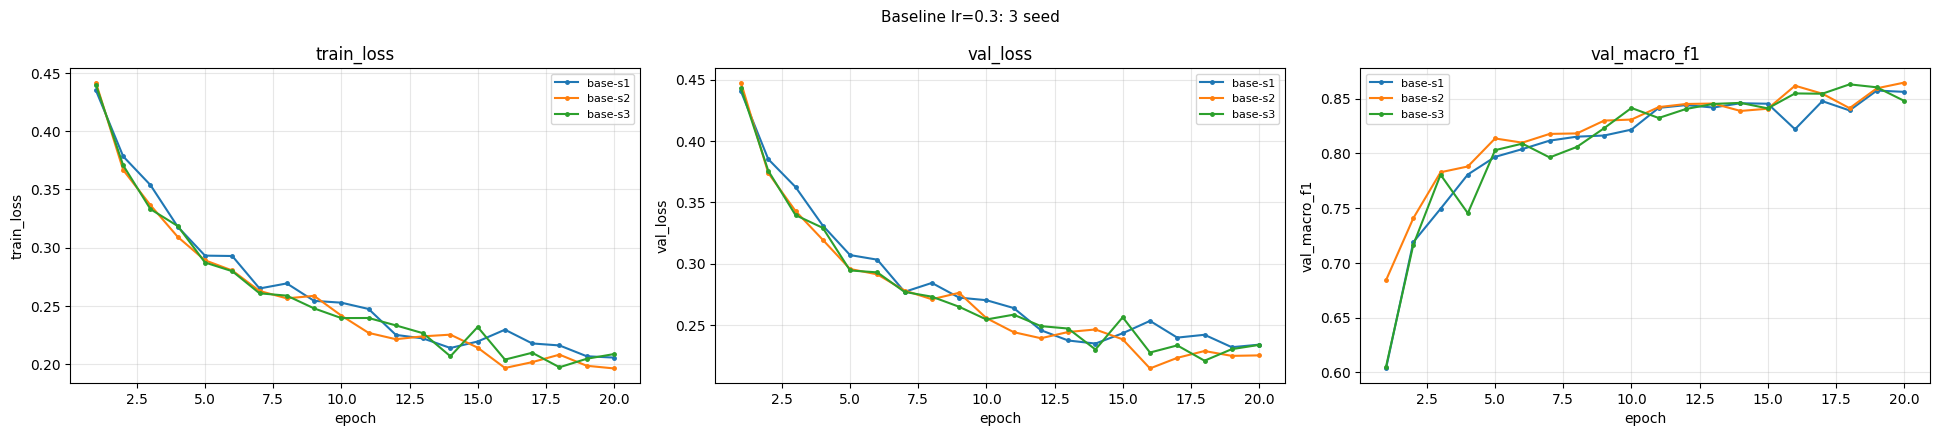

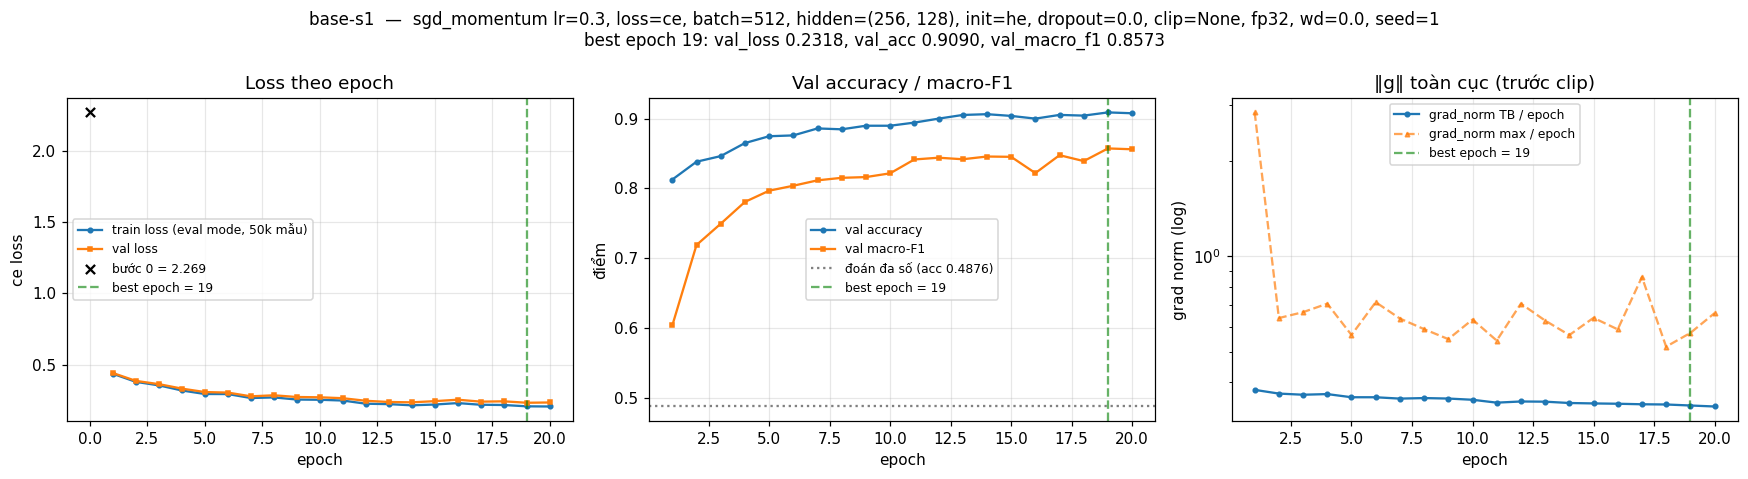

In [4]:
# ===== 2b. Baseline với 3 seed -> độ nhiễu giữa các seed =====
SEEDS = [1, 2, 3]
base_runs = []
for s in SEEDS:
    cfg_s = {**cfg, "seed": s, "exp_id": f"base-s{s}", "group": "baseline",
             "description": f"Baseline M-base, lr = {BEST_LR:g}, seed {s}"}
    base_runs.append(run_and_log(cfg_s, data, OUT_DIR))

seed_table = pd.DataFrame([{"exp_id": r["cfg"]["exp_id"], "seed": r["cfg"]["seed"], **{k: r["summary"][k] for k in
             ("step0_loss", "best_epoch", "best_val_loss", "val_acc", "val_macro_f1", "final_train_loss",
              "final_val_loss", "time_per_epoch_s", "peak_mem_MB")}} for r in base_runs])
display(seed_table.round(4))

noise = seed_table[["val_acc", "val_macro_f1", "best_val_loss"]].agg(["mean", "std"])   # std mẫu (ddof = 1)
display(noise.round(4))
SIGMA_F1 = float(noise.loc["std", "val_macro_f1"])
BASE_F1 = float(noise.loc["mean", "val_macro_f1"])
print(f"val macro-F1 baseline = {BASE_F1:.4f} ± {SIGMA_F1:.4f}  ->  ngưỡng nhiễu 2σ = {2 * SIGMA_F1:.4f}")
print(f"val acc baseline      = {noise.loc['mean', 'val_acc']:.4f} ± {noise.loc['std', 'val_acc']:.4f}  (mốc đoán đa số 0.4876)")

# base-s1 cùng cấu hình + seed với base-lr<BEST_LR>: kiểm tra chạy lặp lại được
same = next(r for r in lr_runs if r["cfg"]["lr"] == BEST_LR)
print("base-s1 lặp lại base-lr%g: chênh val_macro_f1 = %.2e" % (BEST_LR, abs(same["summary"]["val_macro_f1"] - base_runs[0]["summary"]["val_macro_f1"])))

plot_compare(base_runs, ["train_loss", "val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_baseline-seeds.png",
             title=f"Baseline lr={BEST_LR:g}: 3 seed", show=True)
display(Image(f"{OUT_DIR}/figures/base-s1.png"))


**Nhận xét baseline:**
- **Chọn lr bằng val** (SGD + momentum 0,9, seed 1, 20 epoch, mọi thứ khác giữ baseline): lưới lr = 0,003 / 0,01 / 0,03 / 0,1 / 0,3 cho val macro-F1 lần lượt 0,6647 / 0,7613 / 0,8170 / 0,8390 / **0,8573** (`base-lr*`, ảnh `compare_baseline-lr.png`). Chọn **lr = 0,3** vì có val macro-F1 và val loss (0,2318) tốt nhất. Chênh 0,3 so với 0,1 là 0,018, lớn hơn 2σ_seed = 0,006, nên khác biệt này vượt nhiễu (dù mỗi lr chỉ chạy 1 seed). Eval không được dùng ở bước này. **Hạn chế:** 0,3 là giá trị lớn nhất của lưới nên chưa loại trừ được lr lớn hơn còn tốt hơn.
- **lr nhỏ học chậm:** với cùng 20 epoch (727 bước/epoch), lr 0,003 chỉ đạt macro-F1 0,66, val loss vẫn đang giảm đều, tức thiếu số bước/độ lớn bước để hội tụ chứ không phải mô hình thiếu năng lực.
- **Hình dạng đường cong (lr 0,3, `base-s1.png`, `compare_baseline-seeds.png`):** train loss (eval mode, 50k mẫu) và val loss giảm nhanh trong 5 epoch đầu rồi chậm lại, có răng cưa nhẹ do bước lớn; best epoch rơi vào **16–19**, tức **gần như chưa hội tụ**, train nhiều epoch hơn có thể còn cải thiện. Khoảng cách train–val nhỏ (epoch 20: 0,206 / 0,234 ở seed 1) → **chưa quá khớp**. grad_norm trung bình ổn định khoảng 0,33–0,38, chỉ có gai ở các bước đầu epoch 1 (max 2,84).
- **So với mốc:** val accuracy 0,912 ≫ 0,4876 của "đoán lớp đa số"; macro-F1 0,861 ≫ 0,094.
- **Độ nhiễu seed (3 seed, lr 0,3):** val macro-F1 = **0,8607 ± 0,0030**, val acc = 0,9118 ± 0,0027, best val loss = 0,2224 ± 0,0088 (σ là độ lệch chuẩn mẫu). **Ngưỡng nhiễu dùng cho các so sánh sau: 2σ = 0,006 (val macro-F1).** Chênh lệch nhỏ hơn mức này sẽ được coi là chưa kết luận được. Hạn chế: 3 seed là ít, ước lượng σ còn thô.
- `base-s1` cho kết quả trùng khớp hoàn toàn với `base-lr0.3` (cùng cấu hình và seed) → pipeline chạy lặp lại được trên GPU này.
- Loss bước 0 thay đổi theo seed (2,27 / 1,98 / 1,90), cùng quanh ln 7 = 1,946: độ lệch đến từ khởi tạo ngẫu nhiên của lớp cuối (xem Part 1).


## Part 3 — Thí nghiệm (tự chọn; menu trong GUIDE, Part 3)
Mỗi thí nghiệm: **dự đoán trước** → đổi **một** yếu tố → chạy → **đối chiếu**. Lặp lại khối dưới cho từng thí nghiệm bạn chọn.
Chủ đề: loss · optimizer · hparam · dropout · clipping · amp · init.

### Thí nghiệm hyper-parameter: độ rộng (`hp-wide`) và số epoch (`hp-ep40`)
Chủ đề duy nhất của bài: **hyper-parameter**. Mỗi thí nghiệm đổi **một** yếu tố so với baseline (`base-s1`: M-base, SGD+momentum 0,9, lr 0,3, batch 512, 20 epoch, He, seed 1); cùng phép tách val, cùng seed.

**Căn cứ:** baseline chưa hội tụ (best epoch 16–19, val loss còn giảm) và chưa quá khớp (train loss ≈ val loss, 0,206 / 0,234) → theo bảng chẩn đoán đây là "chưa khớp": thiếu năng lực hoặc thiếu thời gian.

**Dự đoán trước khi chạy:**
- `hp-wide` (M-wide 54→512→256→7, 161 287 tham số, vẫn 20 epoch): nhiều tham số hơn → khớp train tốt hơn trong cùng số bước, train loss và val loss thấp hơn baseline; val macro-F1 tăng rõ, vượt 2σ = 0,006. Mỗi epoch chậm hơn một chút (nhiều phép nhân hơn) nhưng số bước cập nhật không đổi (727/epoch).
- `hp-ep40` (M-base, 40 epoch = 29 080 bước thay vì 14 540): val loss tiếp tục giảm thêm, best epoch rơi vào nửa sau; val macro-F1 tăng nhưng ít hơn `hp-wide`, vì M-base có năng lực giới hạn. Khoảng cách train–val có thể bắt đầu nới rộng.


[hp-wide] sgd_momentum lr=0.3 batch=512 loss=ce init=he dropout=0.0 clip=None fp32 seed=1 | 161,287 tham số | step0 val_loss=1.9182
  ep  1 | train 0.4115 | val 0.4119 acc 0.8268 F1 0.6580 | gn 0.388 (max 7.05) | 1.2s *
  ep  2 | train 0.3538 | val 0.3600 acc 0.8497 F1 0.7557 | gn 0.364 (max 0.56) | 1.3s *
  ep  3 | train 0.3283 | val 0.3338 acc 0.8617 F1 0.7709 | gn 0.357 (max 0.74) | 1.3s *
  ep  4 | train 0.2859 | val 0.2975 acc 0.8764 F1 0.8074 | gn 0.357 (max 0.57) | 1.2s *
  ep  5 | train 0.2747 | val 0.2852 acc 0.8843 F1 0.8229 | gn 0.350 (max 0.53) | 1.3s *
  ep  6 | train 0.2512 | val 0.2668 acc 0.8921 F1 0.8296 | gn 0.348 (max 0.58) | 1.3s *
  ep  7 | train 0.2412 | val 0.2558 acc 0.8955 F1 0.8372 | gn 0.346 (max 0.52) | 1.2s *
  ep  8 | train 0.2341 | val 0.2534 acc 0.8996 F1 0.8281 | gn 0.343 (max 0.53) | 1.6s *
  ep  9 | train 0.2175 | val 0.2390 acc 0.9034 F1 0.8514 | gn 0.343 (max 0.52) | 4.1s *
  ep 10 | train 0.2161 | val 0.2340 acc 0.9067 F1 0.8546 | gn 0.339 (max 0.5

,exp_id,hidden,epochs,steps,n_params,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,delta_f1_vs_base,verdict,time_per_epoch_s,peak_mem_MB
0,base-s1,"(256, 128)",20,14540,47879,19,0.2318,0.2057,0.2339,0.9090,0.8573,-0.0034,trong nhiễu (chưa kết luận),1.2854,199.1074
1,hp-wide,"(512, 256)",20,14540,161287,20,0.1998,0.1669,0.1998,0.9226,0.8747,0.0140,VƯỢT nhiễu,1.4702,216.0596
2,hp-ep40,"(256, 128)",40,29080,47879,32,0.1995,0.1722,0.2079,0.9232,0.8733,0.0126,VƯỢT nhiễu,1.3293,199.1074


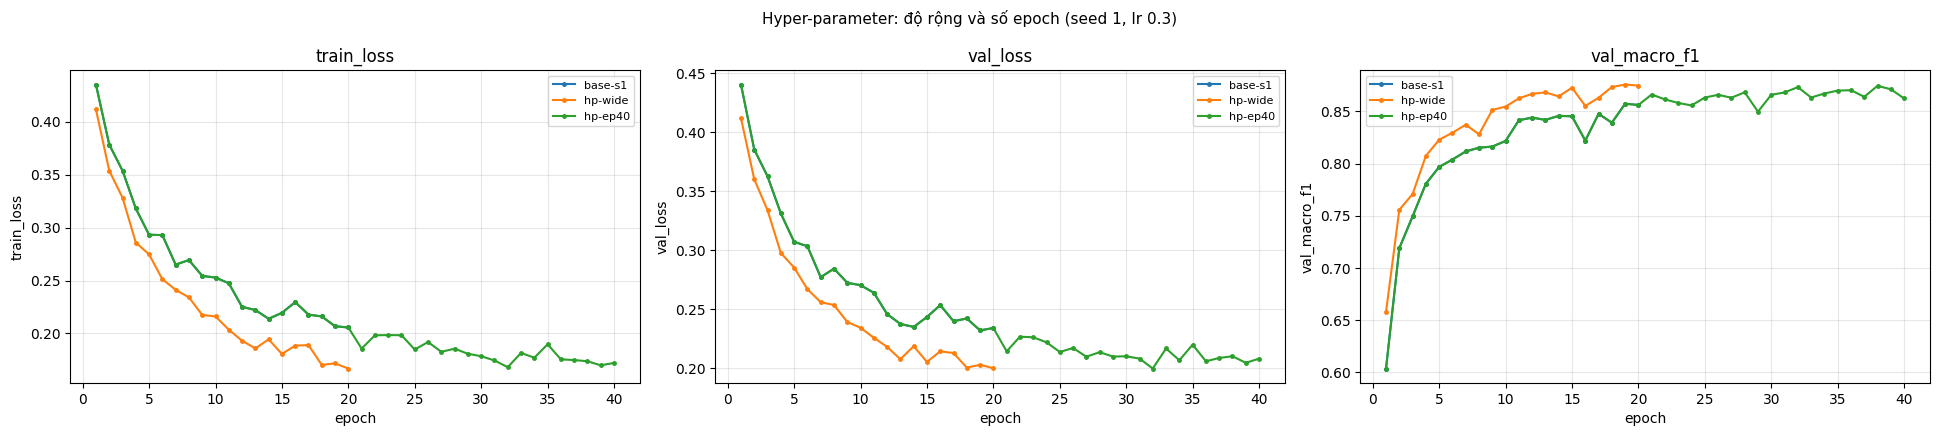

In [5]:
# ===== Part 3: hyper-parameter — đổi MỘT yếu tố so với baseline (lr 0.3, seed 1) =====
def vs_base(r):
    s = r["summary"]; d = s["val_macro_f1"] - BASE_F1
    verdict = "VƯỢT nhiễu" if abs(d) > 2 * SIGMA_F1 else "trong nhiễu (chưa kết luận)"
    return dict(exp_id=r["cfg"]["exp_id"], hidden=str(tuple(r["cfg"]["hidden"])), epochs=r["cfg"]["epochs"],
                steps=s["steps_per_epoch"] * s["epochs_run"], n_params=s["n_params"], best_epoch=s["best_epoch"],
                best_val_loss=s["best_val_loss"], final_train_loss=s["final_train_loss"], final_val_loss=s["final_val_loss"],
                val_acc=s["val_acc"], val_macro_f1=s["val_macro_f1"], delta_f1_vs_base=d, verdict=verdict,
                time_per_epoch_s=s["time_per_epoch_s"], peak_mem_MB=s["peak_mem_MB"])

hp_wide = run_and_log({**cfg, "seed": 1, "exp_id": "hp-wide", "group": "hparam", "hidden": (512, 256),
                       "description": "M-wide 512-256 (161 287 tham số), còn lại như baseline"}, data, OUT_DIR)
hp_ep40 = run_and_log({**cfg, "seed": 1, "exp_id": "hp-ep40", "group": "hparam", "epochs": 40,
                       "description": "M-base, 40 epoch thay vì 20, còn lại như baseline"}, data, OUT_DIR)

print(f"Baseline (3 seed): val macro-F1 = {BASE_F1:.4f} ± {SIGMA_F1:.4f}, 2σ = {2*SIGMA_F1:.4f}")
display(pd.DataFrame([vs_base(r) for r in [base_runs[0], hp_wide, hp_ep40]]).round(4))

plot_compare([base_runs[0], hp_wide, hp_ep40], ["train_loss", "val_loss", "val_macro_f1"],
             f"{OUT_DIR}/figures/compare_hparam.png", title="Hyper-parameter: độ rộng và số epoch (seed 1, lr 0.3)", show=True)


**Đối chiếu sau khi chạy** (số liệu: bảng trên, ảnh `hp-wide.png`, `hp-ep40.png`, `compare_hparam.png`; baseline val macro-F1 = 0,8607 ± 0,0030, 2σ = 0,006):
- **`hp-wide` — khớp dự đoán.** Cùng 20 epoch / 14 540 bước, M-wide đạt val macro-F1 **0,8747** (+0,0140 so với trung bình baseline, > 2σ) và best val loss **0,1998** (baseline 0,2224 ± 0,0088). Train loss cũng thấp hơn ở mọi epoch (epoch 20: 0,1669 so với 0,2057) → đúng là baseline đang **thiếu năng lực**: thêm nơ-ron giúp khớp train tốt hơn, và vì chưa quá khớp nên phần khớp thêm này chuyển thành val tốt hơn. Best epoch vẫn là 20 → vẫn chưa hội tụ. Chi phí: 1,47 s/epoch (+14%) và 216 MB (+17 MB) cho 3,4 lần số tham số — mạng còn rất nhỏ nên GPU chưa bị tải nhiều, thời gian chủ yếu là chi phí gọi kernel theo từng bước chứ không tỉ lệ với số tham số.
- **`hp-ep40` — khớp dự đoán.** 20 epoch đầu trùng khít `base-s1` (cùng seed, cùng thứ tự lô) — so sánh công bằng. Thêm 20 epoch (gấp đôi số bước cập nhật) đưa val loss xuống **0,1995**, best epoch **32**, val macro-F1 **0,8733** (+0,0126, > 2σ). Sau epoch ~32 val loss đi ngang và dao động (0,20–0,22) trong khi train loss vẫn giảm nhẹ → khoảng cách train–val nới ra từ ≈ 0,03 lên ≈ 0,036: **bắt đầu có dấu hiệu bão hoà**, M-base gần hết dư địa với lr cố định 0,3.
- **So hai yếu tố:** `hp-wide` (0,8747) và `hp-ep40` (0,8733) chênh nhau 0,0014 < 2σ → **không kết luận được cái nào tốt hơn**; dự đoán "wide tốt hơn epoch" chưa được xác nhận. Tuy nhiên `hp-wide` đạt mức đó với **một nửa số bước** (14 540 so với 29 080) và tổng thời gian ít hơn (≈ 29 s so với ≈ 53 s).
- **Hạn chế:** mỗi thí nghiệm chỉ chạy 1 seed; ngưỡng 2σ lấy từ độ nhiễu của baseline, giả định độ nhiễu của cấu hình mới tương tự (cấu hình cuối bên dưới chạy 3 seed để kiểm tra).
- **Hướng cấu hình cuối:** hai yếu tố tác động lên hai nguyên nhân khác nhau của "chưa khớp" (năng lực / thời gian) nên kỳ vọng cộng dồn: thử **M-wide + 40 epoch** (đổi 2 yếu tố, cùng chủ đề hyper-parameter), 3 seed, so với baseline bằng val.


[hp-wide-ep40-s1] sgd_momentum lr=0.3 batch=512 loss=ce init=he dropout=0.0 clip=None fp32 seed=1 | 161,287 tham số | step0 val_loss=1.9182
  ep  1 | train 0.4115 | val 0.4119 acc 0.8268 F1 0.6580 | gn 0.388 (max 7.05) | 2.4s *
  ep  2 | train 0.3538 | val 0.3600 acc 0.8497 F1 0.7557 | gn 0.364 (max 0.56) | 1.3s *
  ep  3 | train 0.3283 | val 0.3338 acc 0.8617 F1 0.7709 | gn 0.357 (max 0.74) | 1.3s *
  ep  4 | train 0.2859 | val 0.2975 acc 0.8764 F1 0.8074 | gn 0.357 (max 0.57) | 1.2s *
  ep  5 | train 0.2747 | val 0.2852 acc 0.8843 F1 0.8229 | gn 0.350 (max 0.53) | 1.3s *
  ep  6 | train 0.2512 | val 0.2668 acc 0.8921 F1 0.8296 | gn 0.348 (max 0.58) | 1.3s *
  ep  7 | train 0.2412 | val 0.2558 acc 0.8955 F1 0.8372 | gn 0.346 (max 0.52) | 1.3s *
  ep  8 | train 0.2341 | val 0.2534 acc 0.8996 F1 0.8281 | gn 0.343 (max 0.53) | 1.4s *
  ep  9 | train 0.2175 | val 0.2390 acc 0.9034 F1 0.8514 | gn 0.343 (max 0.52) | 1.5s *
  ep 10 | train 0.2161 | val 0.2340 acc 0.9067 F1 0.8546 | gn 0.339 

,exp_id,hidden,epochs,steps,n_params,best_epoch,best_val_loss,final_train_loss,final_val_loss,val_acc,val_macro_f1,delta_f1_vs_base,verdict,time_per_epoch_s,peak_mem_MB
0,hp-wide-ep40-s1,"(512, 256)",40,29080,161287,38,0.1677,0.1286,0.1737,0.9366,0.8952,0.0345,VƯỢT nhiễu,1.3770,216.0596
1,hp-wide-ep40-s2,"(512, 256)",40,29080,161287,35,0.1742,0.1404,0.1836,0.9327,0.8873,0.0266,VƯỢT nhiễu,1.3463,216.0596
2,hp-wide-ep40-s3,"(512, 256)",40,29080,161287,39,0.1796,0.1415,0.1827,0.9322,0.8875,0.0268,VƯỢT nhiễu,1.3665,216.0596


Cấu hình cuối: val macro-F1 = 0.8900 ± 0.0045  |  baseline = 0.8607 ± 0.0030
Chênh = +0.0293  (2σ baseline = 0.0060)
  hp-wide-ep40-s1: best epoch (val loss thấp nhất) = 38
  hp-wide-ep40-s2: best epoch (val loss thấp nhất) = 35
  hp-wide-ep40-s3: best epoch (val loss thấp nhất) = 39


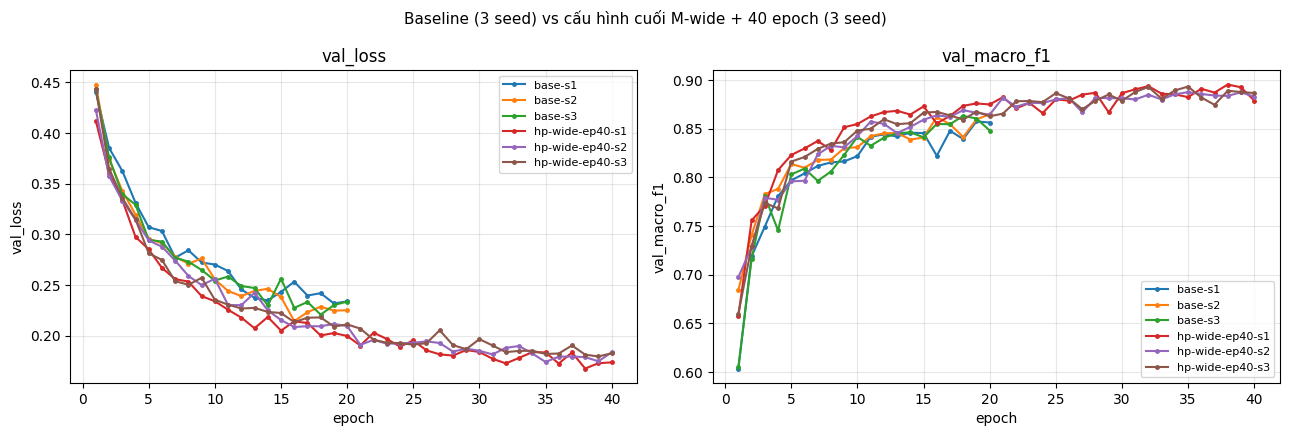

In [6]:
# ===== Cấu hình cuối cùng (ứng viên): kết hợp M-wide + 40 epoch, 3 seed -> so baseline bằng VAL =====
# Ghi chú: đổi 2 yếu tố cùng lúc (cùng chủ đề hyper-parameter) — đã ghi rõ trong description.
final_runs = [run_and_log({**cfg, "seed": s, "exp_id": f"hp-wide-ep40-s{s}", "group": "final", "hidden": (512, 256),
                           "epochs": 40, "description": "Cấu hình cuối: M-wide + 40 epoch (2 yếu tố, kết hợp từ hp-wide và hp-ep40)"},
                          data, OUT_DIR) for s in SEEDS]
display(pd.DataFrame([vs_base(r) for r in final_runs]).round(4))

f1s = np.array([r["summary"]["val_macro_f1"] for r in final_runs])
FINAL_F1, FINAL_SIGMA = f1s.mean(), f1s.std(ddof=1)
print(f"Cấu hình cuối: val macro-F1 = {FINAL_F1:.4f} ± {FINAL_SIGMA:.4f}  |  baseline = {BASE_F1:.4f} ± {SIGMA_F1:.4f}")
print(f"Chênh = {FINAL_F1 - BASE_F1:+.4f}  (2σ baseline = {2*SIGMA_F1:.4f})")
for r in final_runs:
    print(f"  {r['cfg']['exp_id']}: best epoch (val loss thấp nhất) = {r['summary']['best_epoch']}")

plot_compare(base_runs + final_runs, ["val_loss", "val_macro_f1"], f"{OUT_DIR}/figures/compare_final.png",
             title="Baseline (3 seed) vs cấu hình cuối M-wide + 40 epoch (3 seed)", show=True)


**Đối chiếu cấu hình cuối + quyết định (chỉ dựa trên VAL, trước khi chạm vào eval):**
- **Kết hợp M-wide + 40 epoch** (đổi 2 yếu tố cùng chủ đề hyper-parameter, ghi trong `description`), 3 seed: val macro-F1 = **0,8900 ± 0,0046**, so với baseline **0,8607 ± 0,0030** → chênh **+0,0293**, gần 5 lần 2σ_baseline = 0,006 và cả 3 seed của cấu hình cuối (0,8873–0,8952) đều cao hơn seed tốt nhất của baseline (0,8630) → khác biệt **vượt nhiễu**. Val loss tốt nhất 0,168–0,180 so với 0,215–0,232 của baseline (`compare_final.png`).
- **Khớp dự đoán "cộng dồn":** cấu hình cuối (0,8900) tốt hơn từng yếu tố riêng lẻ (`hp-wide` 0,8747, `hp-ep40` 0,8733, 1 seed): mạng rộng hơn cho năng lực, thêm epoch cho thời gian để dùng năng lực đó. 20 epoch đầu của `hp-wide-ep40-s1` trùng khít `hp-wide` (cùng seed) → phần cải thiện thêm đến từ 20 epoch sau.
- **Chưa quá khớp nặng:** ở best epoch, train loss (≈ 0,13–0,14) chỉ thấp hơn val loss ≈ 0,03–0,04; best epoch 35–39 → val loss vẫn còn giảm chậm tới cuối, tức vẫn chưa hội tụ hẳn — train lâu hơn có thể cải thiện thêm (chưa thử, ngoài phạm vi).
- **Chi phí:** 161 287 tham số (gấp 3,4 lần), ≈ 1,37 s/epoch × 40 epoch ≈ 55 s mỗi lần chạy (baseline ≈ 26 s), bộ nhớ đỉnh 216 MB (baseline 199 MB).
- Loss bước 0 của M-wide thay đổi mạnh theo seed (1,92 / 2,65 / 2,79): lớp cuối có fan-in 256 thay vì 128 nên logits ban đầu lớn hơn với He init — lại là hiệu ứng khởi tạo lớp cuối như ở Part 1, không ảnh hưởng tới kết quả sau vài epoch.

**QUYẾT ĐỊNH (chốt trước Part 4):**
- **Cấu hình cuối cùng:** M-wide (54→512→256→7, 161 287 tham số), He init, CE, SGD + momentum 0,9, **lr 0,3**, batch 512, **40 epoch**, dropout 0, không clip, FP32.
- **Mô hình nộp:** `hp-wide-ep40-s1` (seed 1) — cùng seed 1 như mọi thí nghiệm đơn lẻ, đồng thời có val loss thấp nhất trong 3 seed; dùng trọng số tại **best epoch = 38** (val loss thấp nhất 0,1677).
- **Baseline để so trên eval:** `base-s1` (seed 1, lr 0,3, 20 epoch), trọng số tại **best epoch = 19** (val loss 0,2318).
- Eval chỉ được chạy **một lần** cho hai mô hình này ở Part 4; không chỉnh lại cấu hình sau khi thấy điểm eval. Độ nhiễu trên val của cấu hình cuối (σ = 0,0046) dùng để diễn giải điểm eval.


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [8]:
# ===== 4a. Đánh giá cuối trên eval: baseline và cấu hình cuối (chạy MỘT lần) =====
import importlib, results_table
importlib.reload(results_table)                       # nạp to_row / write_xlsx mới mà không mất biến
from results_table import load_results, to_row, write_xlsx
from train import final_eval

FINAL_RUN, BASE_RUN = final_runs[0], base_runs[0]     # đã chốt ở Part 3 bằng val
assert FINAL_RUN["cfg"]["exp_id"] == "hp-wide-ep40-s1" and BASE_RUN["cfg"]["exp_id"] == "base-s1"
REPO_ABS, OUT_ABS = os.path.abspath(REPO_ROOT), os.path.abspath(OUT_DIR)

def official_eval(pred_path, json_path):
    """Chạy đúng script chấm của giảng viên (từ gốc repo) và in nguyên output."""
    r = subprocess.run([sys.executable, "scripts/evaluate.py", "--pred", pred_path, "--out", json_path],
                       cwd=REPO_ABS, capture_output=True, text=True, encoding="utf-8",
                       env={**os.environ, "PYTHONIOENCODING": "utf-8"})
    print(r.stdout, r.stderr)
    assert r.returncode == 0, "evaluate.py báo lỗi — xem thông báo ở trên"
    with open(json_path, encoding="utf-8") as f:
        return json.load(f)

# Baseline: bằng chứng riêng, KHÔNG phải file nộp
os.makedirs(f"{OUT_ABS}/eval_baseline", exist_ok=True)
final_eval(BASE_RUN["cfg"], BASE_RUN, data, f"{OUT_ABS}/eval_baseline/predictions_eval_baseline.csv")
print(f"===== BASELINE {BASE_RUN['cfg']['exp_id']} (best epoch {BASE_RUN['summary']['best_epoch']}) =====")
eval_base = official_eval(f"{OUT_ABS}/eval_baseline/predictions_eval_baseline.csv",
                          f"{OUT_ABS}/eval_baseline/eval_result_baseline.json")

# Cấu hình cuối: FILE NỘP predictions_eval.csv + eval_result.json
final_eval(FINAL_RUN["cfg"], FINAL_RUN, data, f"{OUT_ABS}/predictions_eval.csv")
print(f"===== CẤU HÌNH CUỐI {FINAL_RUN['cfg']['exp_id']} (seed {FINAL_RUN['cfg']['seed']}, best epoch {FINAL_RUN['summary']['best_epoch']}) =====")
eval_final = official_eval(f"{OUT_ABS}/predictions_eval.csv", f"{OUT_ABS}/eval_result.json")

assert eval_final["n_eval"] == 116_203
summary_eval = pd.DataFrame([
    dict(config="baseline", exp_id=BASE_RUN["cfg"]["exp_id"], seed=BASE_RUN["cfg"]["seed"],
         best_epoch=BASE_RUN["summary"]["best_epoch"], val_macro_f1=BASE_RUN["summary"]["val_macro_f1"],
         eval_macro_f1=eval_base["macro_f1"], eval_acc=eval_base["accuracy"]),
    dict(config="cuối cùng", exp_id=FINAL_RUN["cfg"]["exp_id"], seed=FINAL_RUN["cfg"]["seed"],
         best_epoch=FINAL_RUN["summary"]["best_epoch"], val_macro_f1=FINAL_RUN["summary"]["val_macro_f1"],
         eval_macro_f1=eval_final["macro_f1"], eval_acc=eval_final["accuracy"]),
])
summary_eval["eval_minus_val"] = summary_eval["eval_macro_f1"] - summary_eval["val_macro_f1"]
display(summary_eval.round(4))
print(f"Cải thiện eval macro-F1 (cuối - baseline) = {eval_final['macro_f1'] - eval_base['macro_f1']:+.4f}"
      f"   | σ seed trên val: baseline {SIGMA_F1:.4f}, cấu hình cuối {FINAL_SIGMA:.4f}")


===== BASELINE base-s1 (best epoch 19) =====
n_eval = 116203
accuracy = 0.9089
macro_f1 = 0.8565   <- chỉ số chính

lớp  support  precision  recall    f1
  0    42368     0.9304  0.8798  0.9044
  1    56661     0.9025  0.9514  0.9263
  2     7151     0.9303  0.8610  0.8943
  3      549     0.8330  0.7723  0.8015
  4     1899     0.8195  0.7077  0.7595
  5     3473     0.7670  0.8557  0.8089
  6     4102     0.9405  0.8632  0.9002

ma trận nhầm lẫn (hàng = thật, cột = dự đoán):
       0      1     2    3     4     5     6
0  37274   4837     1    0    44     9   203
1   2225  53908    87    0   237   183    21
2     13    271  6157   67    14   629     0
3      0      0    57  424     0    68     0
4     26    494    21    0  1344    14     0
5     17    170   295   18     1  2972     0
6    506     55     0    0     0     0  3541

đã ghi /content/drive/MyDrive/K4-Track4-DangHuuTam-2A202602940-Neuralnetwork/submission_2A202602940/eval_baseline/eval_result_baseline.json
 
===== CẤU HÌNH 

,config,exp_id,seed,best_epoch,val_macro_f1,eval_macro_f1,eval_acc,eval_minus_val
0,baseline,base-s1,1,19,0.8573,0.8565,0.9089,-0.0009
1,cuối cùng,hp-wide-ep40-s1,1,38,0.8952,0.8946,0.9356,-0.0006


Cải thiện eval macro-F1 (cuối - baseline) = +0.0382   | σ seed trên val: baseline 0.0030, cấu hình cuối 0.0045


,lớp,support,precision,recall,f1,f1_baseline,delta_f1,tỉ lệ (%)
cls,,,,,,,,
0,0 Spruce/Fir,42368,0.9378,0.9329,0.9354,0.9044,0.0310,36.4603
1,1 Lodgepole Pine,56661,0.9446,0.9471,0.9458,0.9263,0.0196,48.7604
2,2 Ponderosa Pine,7151,0.9287,0.9241,0.9264,0.8943,0.0321,6.1539
3,3 Cottonwood/Willow,549,0.8877,0.7778,0.8291,0.8015,0.0276,0.4724
4,4 Aspen,1899,0.8489,0.7957,0.8214,0.7595,0.0619,1.6342
5,5 Douglas-fir,3473,0.8245,0.9035,0.8622,0.8089,0.0533,2.9887
6,6 Krummholz,4102,0.9468,0.9371,0.9419,0.9002,0.0417,3.5300


,đoán 0,đoán 1,đoán 2,đoán 3,đoán 4,đoán 5,đoán 6
thật 0,39527,2614,1,0,24,8,194
thật 1,2345,53664,177,0,224,229,22
thật 2,4,111,6608,40,12,376,0
thật 3,0,1,77,427,0,44,0
thật 4,40,322,15,0,1511,11,0
thật 5,7,68,237,14,9,3138,0
thật 6,226,32,0,0,0,0,3844


Mỗi lớp thật hay bị đoán nhầm thành lớp nào nhất:
  lớp 0: recall 0.933 | nhầm nhiều nhất -> lớp 1 (6.2%, 2614 mẫu)
  lớp 1: recall 0.947 | nhầm nhiều nhất -> lớp 0 (4.1%, 2345 mẫu)
  lớp 2: recall 0.924 | nhầm nhiều nhất -> lớp 5 (5.3%, 376 mẫu)
  lớp 3: recall 0.778 | nhầm nhiều nhất -> lớp 2 (14.0%, 77 mẫu)
  lớp 4: recall 0.796 | nhầm nhiều nhất -> lớp 1 (17.0%, 322 mẫu)
  lớp 5: recall 0.904 | nhầm nhiều nhất -> lớp 2 (6.8%, 237 mẫu)
  lớp 6: recall 0.937 | nhầm nhiều nhất -> lớp 0 (5.5%, 226 mẫu)

Lớp khó nhất theo F1: lớp 4 (4 Aspen), F1 = 0.8214


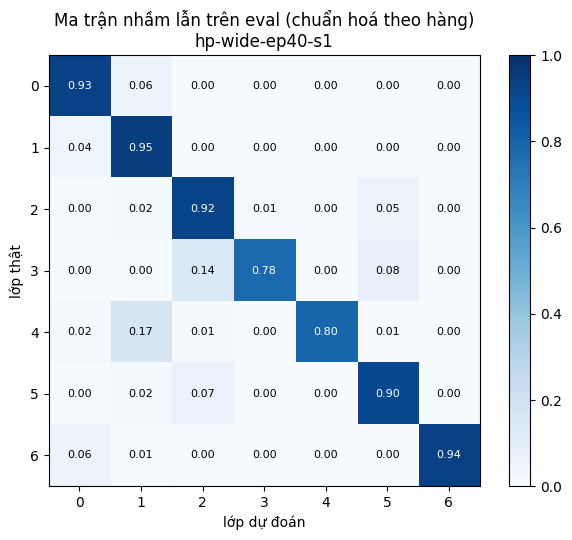

In [9]:
# ===== 4b. Phân tích lỗi theo lớp (từ eval_result.json; hàng = nhãn thật, cột = dự đoán) =====
import matplotlib.pyplot as plt
CLASS_NAMES = ["0 Spruce/Fir", "1 Lodgepole Pine", "2 Ponderosa Pine", "3 Cottonwood/Willow",
               "4 Aspen", "5 Douglas-fir", "6 Krummholz"]
pc = pd.DataFrame(eval_final["per_class"]).set_index("cls")
pc["f1_baseline"] = [c["f1"] for c in eval_base["per_class"]]
pc["delta_f1"] = pc["f1"] - pc["f1_baseline"]
pc.insert(0, "lớp", CLASS_NAMES)
pc["tỉ lệ (%)"] = 100 * pc["support"] / pc["support"].sum()
display(pc.round(4))

cm = np.array(eval_final["confusion_matrix"])
cm_df = pd.DataFrame(cm, index=[f"thật {c}" for c in range(7)], columns=[f"đoán {c}" for c in range(7)])
display(cm_df)
cm_row = cm / cm.sum(1, keepdims=True)                 # chuẩn hoá theo hàng = phân bố dự đoán của mỗi lớp thật
print("Mỗi lớp thật hay bị đoán nhầm thành lớp nào nhất:")
for c in range(7):
    off = cm_row[c].copy(); off[c] = -1; j = int(off.argmax())
    print(f"  lớp {c}: recall {cm_row[c, c]:.3f} | nhầm nhiều nhất -> lớp {j} ({cm_row[c, j]:.1%}, {cm[c, j]} mẫu)")
hardest = int(pc["f1"].idxmin())
print(f"\nLớp khó nhất theo F1: lớp {hardest} ({CLASS_NAMES[hardest]}), F1 = {pc.loc[hardest, 'f1']:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm_row, cmap="Blues", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        ax.text(j, i, f"{cm_row[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if cm_row[i, j] > 0.5 else "black")
ax.set_xticks(range(7)); ax.set_yticks(range(7))
ax.set_xlabel("lớp dự đoán"); ax.set_ylabel("lớp thật")
ax.set_title(f"Ma trận nhầm lẫn trên eval (chuẩn hoá theo hàng)\n{FINAL_RUN['cfg']['exp_id']}")
fig.colorbar(im, ax=ax, fraction=0.046); plt.tight_layout(); plt.show()   # chỉ hiển thị, không lưu vào figures/


**Phân tích lỗi trên eval** (`eval_result.json` của `hp-wide-ep40-s1`; hàng = nhãn thật, cột = dự đoán; so với `eval_baseline/eval_result_baseline.json`):

| Lớp | support (tỉ lệ) | precision | recall | F1 | F1 baseline | ΔF1 |
|---|---|---|---|---|---|---|
| 0 Spruce/Fir | 42 368 (36,5%) | 0,9378 | 0,9329 | 0,9354 | 0,9044 | +0,031 |
| 1 Lodgepole Pine | 56 661 (48,8%) | 0,9446 | 0,9471 | 0,9458 | 0,9263 | +0,020 |
| 2 Ponderosa Pine | 7 151 (6,2%) | 0,9287 | 0,9241 | 0,9264 | 0,8943 | +0,032 |
| 3 Cottonwood/Willow | 549 (0,5%) | 0,8877 | 0,7778 | 0,8291 | 0,8015 | +0,028 |
| **4 Aspen** | 1 899 (1,6%) | 0,8489 | 0,7957 | **0,8214** | 0,7595 | +0,062 |
| 5 Douglas-fir | 3 473 (3,0%) | 0,8245 | 0,9035 | 0,8622 | 0,8089 | +0,053 |
| 6 Krummholz | 4 102 (3,5%) | 0,9468 | 0,9371 | 0,9419 | 0,9002 | +0,042 |

**Điều ma trận cho thấy (đo được):**
- **Lớp khó nhất: lớp 4 (Aspen), F1 = 0,8214**, recall chỉ 0,796: **17,0%** mẫu Aspen thật (322/1 899) bị đoán thành **lớp 1 (Lodgepole Pine)**, thêm 2,1% thành lớp 0. Lớp 3 (Cottonwood/Willow) đứng thứ hai (F1 0,829, recall 0,778): bị nhầm sang **lớp 2** (14,0%, 77 mẫu) và **lớp 5** (8,0%, 44 mẫu).
- Lớp 5 (Douglas-fir) có precision thấp nhất (0,825): 668 mẫu bị đoán nhầm *vào* lớp 5, chủ yếu từ lớp 2 (376) và lớp 1 (229) — ba lớp 2, 3, 5 nhầm qua lại với nhau.
- Về số lượng tuyệt đối, cặp **0 ↔ 1** chiếm **4 959 / 7 484 lỗi (66%)** (2 614 + 2 345), nhưng vì hai lớp này rất lớn nên F1 của chúng vẫn ~0,94. Đây là lý do accuracy (0,936) cao hơn macro-F1 (0,895): macro-F1 bị kéo xuống bởi các lớp hiếm.
- So với baseline, cấu hình cuối cải thiện F1 ở **cả 7 lớp**, nhiều nhất ở các lớp nhỏ (lớp 4 +0,062, lớp 5 +0,053, lớp 6 +0,042), ít nhất ở lớp lớn 1 (+0,020).

**Giả thuyết giải thích (chưa kiểm chứng bằng thí nghiệm):**
- **Ít mẫu + mất cân bằng:** lớp 4 (1,6%) và lớp 3 (0,5%) đóng góp rất ít vào cross-entropy trung bình, nên gradient ưu tiên ranh giới của lớp lớn; khi phân vân, mô hình nghiêng về lớp đa số láng giềng (Aspen → Lodgepole). Phù hợp với việc chúng có recall thấp hơn precision.
- **Đặc trưng địa hình chồng lấn:** Aspen và Lodgepole Pine mọc ở cùng dải độ cao trung bình; Cottonwood/Willow, Ponderosa Pine và Douglas-fir cùng tập trung ở vùng thấp. Với 54 đặc trưng địa hình, các cặp này khó tách. Đây là kiến thức nền về bộ dữ liệu, *chưa* được kiểm tra bằng thống kê đặc trưng theo lớp trong bài này.
- **Cách cải thiện sẽ thử (chưa chạy):** trọng số lớp trong cross-entropy (ngược tần suất) hoặc lấy mẫu cân bằng để tăng recall của lớp 3/4; kiểm tra bằng F1 từng lớp trên **val** trước khi đánh giá lại.
- **Hạn chế:** đây là một mô hình (seed 1); chưa đo độ dao động của F1 từng lớp giữa các seed.

In [10]:
# ===== 4c. Bảng experiments.xlsx (mỗi lần chạy một dòng; eval chỉ cho baseline và cấu hình cuối) =====
results = load_results(f"{OUT_DIR}/results")
EVAL_BY_ID = {BASE_RUN["cfg"]["exp_id"]: eval_base, FINAL_RUN["cfg"]["exp_id"]: eval_final}
NOTES = {
    f"base-lr{BEST_LR:g}": f"trùng cấu hình + seed với base-s1 (kiểm tra chạy lặp lại)",
    "base-s1": "baseline chính thức; đánh giá eval (predictions riêng trong eval_baseline/)",
    "hp-wide": "đổi 1 yếu tố: hidden 512-256 (M-wide)",
    "hp-ep40": "đổi 1 yếu tố: 40 epoch; 20 epoch đầu trùng base-s1",
    "hp-wide-ep40-s1": "CẤU HÌNH CUỐI, mô hình nộp (predictions_eval.csv); đổi 2 yếu tố: hidden 512-256 + 40 epoch",
}
for s in (2, 3):
    NOTES[f"hp-wide-ep40-s{s}"] = "cấu hình cuối, seed khác để đo nhiễu; đổi 2 yếu tố: hidden 512-256 + 40 epoch"
rows = [to_row(r, EVAL_BY_ID.get(r["cfg"]["exp_id"]), NOTES.get(r["cfg"]["exp_id"], "")) for r in results]
SUMMARY_NOTES = {
    "baseline": f"{len(base_runs)} seed, lr {BEST_LR:g}: val macro-F1 {BASE_F1:.4f} ± {SIGMA_F1:.4f} (2σ = {2*SIGMA_F1:.4f}); chưa hội tụ, chưa quá khớp.",
    "hparam": "Dò lr (base-lr*) chọn 0.3; M-wide (+0.014) và 40 epoch (+0.013) đều vượt 2σ nhưng không khác nhau có ý nghĩa.",
    "final": f"M-wide + 40 epoch, {len(final_runs)} seed: val macro-F1 {FINAL_F1:.4f} ± {FINAL_SIGMA:.4f} (+{FINAL_F1 - BASE_F1:.4f} so với baseline).",
}
write_xlsx(rows, f"{REPO_ROOT}/templates/experiment_table_template.xlsx", f"{OUT_DIR}/experiments.xlsx",
           seed_ids=[r["cfg"]["exp_id"] for r in base_runs], summary_notes=SUMMARY_NOTES)

# Kiểm tra: mỗi dòng có ảnh, số ảnh <exp_id>.png = số dòng, eval chỉ ở 2 dòng
fig_files = sorted(f[:-4] for f in os.listdir(f"{OUT_DIR}/figures") if f.endswith(".png") and not f.startswith("compare_"))
ids = [r["exp_id"] for r in rows]
assert sorted(ids) == fig_files, f"lệch ảnh/dòng: {set(ids) ^ set(fig_files)}"
assert [r["exp_id"] for r in rows if r["eval_macro_f1"] is not None] == sorted(EVAL_BY_ID)
display(pd.DataFrame(rows)[["exp_id", "group", "lr", "hidden", "epochs", "seed", "best_epoch", "val_acc",
                            "val_macro_f1", "eval_acc", "eval_macro_f1", "figure_file"]].round(4))
print(f"Đã ghi {OUT_DIR}/experiments.xlsx: {len(rows)} dòng, {len(fig_files)} ảnh thí nghiệm, "
      f"{len([f for f in os.listdir(f'{OUT_DIR}/figures') if f.startswith('compare_')])} ảnh compare_*.")


,exp_id,group,lr,hidden,epochs,seed,best_epoch,val_acc,val_macro_f1,eval_acc,eval_macro_f1,figure_file
0,base-lr0.003,hparam,0.003,256-128,20,1,20,0.8250,0.6647,NaN,NaN,figures/base-lr0.003.png
1,base-lr0.01,hparam,0.010,256-128,20,1,20,0.8747,0.7613,NaN,NaN,figures/base-lr0.01.png
2,base-lr0.03,hparam,0.030,256-128,20,1,20,0.8921,0.8170,NaN,NaN,figures/base-lr0.03.png
3,base-lr0.1,hparam,0.100,256-128,20,1,18,0.9054,0.8390,NaN,NaN,figures/base-lr0.1.png
4,base-lr0.3,hparam,0.300,256-128,20,1,19,0.9090,0.8573,NaN,NaN,figures/base-lr0.3.png
5,base-s1,baseline,0.300,256-128,20,1,19,0.9090,0.8573,0.9089,0.8565,figures/base-s1.png
6,base-s2,baseline,0.300,256-128,20,2,16,0.9144,0.8618,NaN,NaN,figures/base-s2.png
7,base-s3,baseline,0.300,256-128,20,3,18,0.9121,0.8630,NaN,NaN,figures/base-s3.png
8,hp-ep40,hparam,0.300,256-128,40,1,32,0.9232,0.8733,NaN,NaN,figures/hp-ep40.png
9,hp-wide,hparam,0.300,512-256,20,1,20,0.9226,0.8747,NaN,NaN,figures/hp-wide.png


Đã ghi ../experiments.xlsx: 13 dòng, 13 ảnh thí nghiệm, 4 ảnh compare_*.
